# MIQR-CC — Classificação Automática de Imagens CPRE
**Aprendizagem Profunda — Módulo 2 | Universidade do Minho**

Este notebook implementa uma solução de Deep Learning para classificação de imagens fluoroscópicas de CPRE nas 4 classes diagnósticas: Biliary_Leaks, Lithiasis, Normal, Stricture.

**Baseline a superar:** F1-macro = 0.738 (EfficientNet-B7)

## 1. Imports e Setup

In [ ]:
import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

from sklearn.metrics import (
    f1_score, accuracy_score, confusion_matrix,
    classification_report, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

# Reproducibilidade
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'A usar: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Safe build_model override: tries pretrained=True, falls back to pretrained=False if unavailable
def build_model(model_name, num_classes, pretrained=True):
    try:
        model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)
        return model
    except Exception as e:
        print(f"Warning: failed to load pretrained weights for {model_name}: {e}")
        print("Falling back to pretrained=False (random init)")
        model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
        return model

A usar: cuda
GPU: NVIDIA RTX 6000 Ada Generation


## 2. Configuração de Paths e Hiperparâmetros

In [2]:
# Paths
BASE_DIR    = '../dataset'
MODELS_DIR  = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

# Hiperparâmetros
IMG_SIZE    = 224      # EfficientNetV2 usa 224 por defeito (mais rápido que 512)
BATCH_SIZE  = 16       # Baseline usava 4 — 16 é mais estável
EPOCHS      = 60
LR          = 1e-4
PATIENCE    = 10       # Early stopping
MODEL_NAME  = 'convnext_tiny'   # Modelo via timm com pretrained disponíveis
SAVE_PATH   = os.path.join(MODELS_DIR, f'{MODEL_NAME}.pth')

CLASS_NAMES = sorted([
    d for d in os.listdir(os.path.join(BASE_DIR, 'train'))
    if os.path.isdir(os.path.join(BASE_DIR, 'train', d))
])
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

Classes (4): ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']


## 3. Análise Exploratória (EDA)

Classe                  Train      Val     Test    Total
--------------------------------------------------
Biliary_Leaks             110       24       17      151
Lithiasis                 505       98      123      726
Normal                    197       59       43      299
Stricture                 255       53       84      392


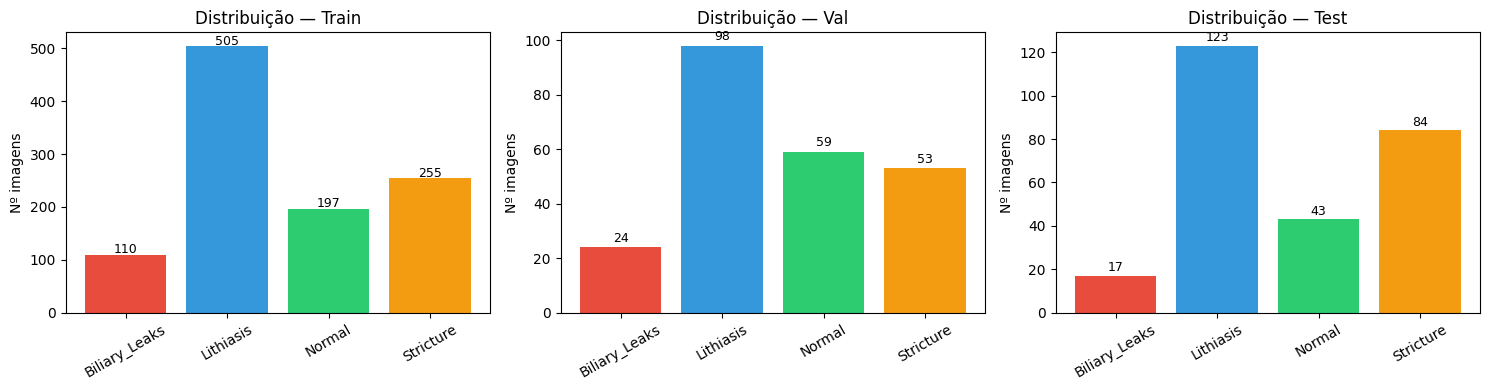


 Nota: Dataset desbalanceado — Lithiasis tem ~5x mais imagens que Biliary_Leaks


In [3]:
def count_images(base_dir, phases, class_names):
    counts = {}
    for phase in phases:
        counts[phase] = {}
        for cls in class_names:
            path = os.path.join(base_dir, phase, cls)
            n = len([f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            counts[phase][cls] = n
    return counts

counts = count_images(BASE_DIR, ['train', 'val', 'test'], CLASS_NAMES)

# Tabela de distribuição
print(f"{'Classe':<20} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print('-' * 50)
for cls in CLASS_NAMES:
    tr = counts['train'][cls]
    va = counts['val'][cls]
    te = counts['test'][cls]
    print(f"{cls:<20} {tr:>8} {va:>8} {te:>8} {tr+va+te:>8}")

# Gráfico de barras
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, phase in enumerate(['train', 'val', 'test']):
    vals = [counts[phase][c] for c in CLASS_NAMES]
    axes[i].bar(CLASS_NAMES, vals, color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
    axes[i].set_title(f'Distribuição — {phase.capitalize()}')
    axes[i].set_ylabel('Nº imagens')
    axes[i].tick_params(axis='x', rotation=30)
    for j, v in enumerate(vals):
        axes[i].text(j, v + 2, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../models/distribuicao_classes.png', dpi=150)
plt.show()
print('\n Nota: Dataset desbalanceado — Lithiasis tem ~5x mais imagens que Biliary_Leaks')

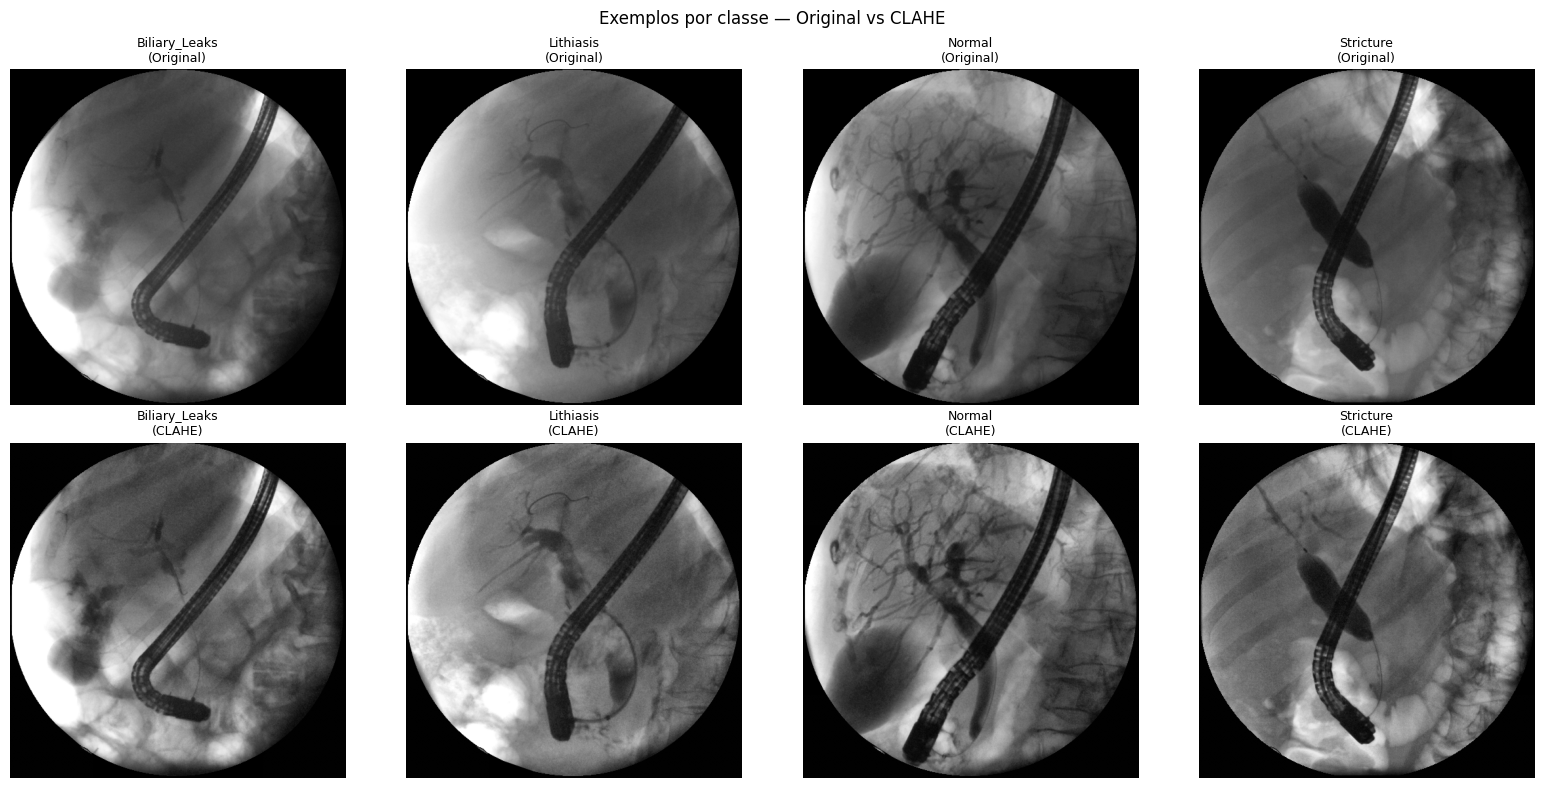

In [4]:
# Visualizar exemplos de cada classe + efeito CLAHE
def apply_clahe(img_array):
    """Aplica CLAHE a imagem grayscale para melhorar contraste local"""
    if len(img_array.shape) == 3:
        gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    else:
        gray = img_array
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(gray)

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(16, 8))
for j, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(BASE_DIR, 'train', cls)
    img_path = os.path.join(cls_dir, os.listdir(cls_dir)[0])
    img = np.array(Image.open(img_path).convert('RGB'))
    clahe_img = apply_clahe(img)
    
    axes[0, j].imshow(img, cmap='gray')
    axes[0, j].set_title(f'{cls}\n(Original)', fontsize=9)
    axes[0, j].axis('off')
    
    axes[1, j].imshow(clahe_img, cmap='gray')
    axes[1, j].set_title(f'{cls}\n(CLAHE)', fontsize=9)
    axes[1, j].axis('off')

plt.suptitle('Exemplos por classe — Original vs CLAHE', fontsize=12)
plt.tight_layout()
plt.savefig('../models/exemplos_clahe.png', dpi=150)
plt.show()

## 4. Dataset e Transforms

**Melhorias face à baseline:**
- CLAHE aplicado antes dos outros transforms (melhora contraste em imagens médicas)
- Flip horizontal adicionado (augmentation extra)
- Batch size 16 em vez de 4

In [5]:
class CLAHETransform:
    """Transform customizado que aplica CLAHE e converte para RGB"""
    def __init__(self, clip_limit=2.0, tile_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)

    def __call__(self, img):
        img_np = np.array(img)
        if len(img_np.shape) == 3:
            gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        else:
            gray = img_np
        enhanced = self.clahe.apply(gray)
        # Converte de volta para RGB (3 canais) para o modelo
        enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(enhanced_rgb)


# Transforms de treino — augmentation mais leve
train_transforms = T.Compose([
    CLAHETransform(clip_limit=2.0),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

# Transforms de validação/teste — sem augmentation
val_transforms = T.Compose([
    CLAHETransform(clip_limit=2.0),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

print('Transforms definidos.')

Transforms definidos.


In [6]:
class CPREDataset(Dataset):
    def __init__(self, base_dir, phase, class_names, transform=None):
        self.transform = transform
        self.class_names = class_names
        self.samples = []  # (path, label)
        
        for label, cls in enumerate(class_names):
            cls_dir = os.path.join(base_dir, phase, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append((os.path.join(cls_dir, fname), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


# Criar datasets
train_ds = CPREDataset(BASE_DIR, 'train', CLASS_NAMES, train_transforms)
val_ds   = CPREDataset(BASE_DIR, 'val',   CLASS_NAMES, val_transforms)
test_ds  = CPREDataset(BASE_DIR, 'test',  CLASS_NAMES, val_transforms)

# Diagnóstico do desequilíbrio (mantido só para reporte)
train_labels = [s[1] for s in train_ds.samples]
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_labels,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print('Class weights:', {CLASS_NAMES[i]: f"{class_weights[i]:.3f}" for i in range(NUM_CLASSES)})

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f'\nTreino: {len(train_ds)} | Validação: {len(val_ds)} | Teste: {len(test_ds)}')

Class weights: {'Biliary_Leaks': '2.425', 'Lithiasis': '0.528', 'Normal': '1.354', 'Stricture': '1.046'}

Treino: 1067 | Validação: 234 | Teste: 267


## 5. Modelo — EfficientNetV2-S

EfficientNetV2-S é mais moderno e eficiente que o EfficientNet-B7 da baseline, com melhor desempenho a 224x224.

In [ ]:
def build_model(model_name, num_classes, pretrained=True):
    model = timm.create_model(
        model_name,
        pretrained=pretrained,
        num_classes=num_classes,
        drop_rate=0.2,
        drop_path_rate=0.2,
    )
    return model

# Use pretrained weights for transfer learning
model = build_model(MODEL_NAME, NUM_CLASSES, pretrained=True)
model = model.to(DEVICE)

# Contar parâmetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parâmetros totais:    {total_params:,}')
print(f'Parâmetros treináveis: {trainable_params:,}')

# Loss com class weights (trata desbalanceamento)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

def is_head_param(name):
    name_l = name.lower()
    return any(token in name_l for token in ('classifier', 'head', 'fc', 'last_linear'))

backbone_params = [param for name, param in model.named_parameters() if not is_head_param(name)]
head_params = [param for name, param in model.named_parameters() if is_head_param(name)]

# Optimizer e scheduler
optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': LR * 0.01},
    {'params': head_params, 'lr': LR},
], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f'\nModelo: {MODEL_NAME} | Loss: CrossEntropyLoss com class weights | Optimizer: AdamW')

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Parâmetros totais:    27,823,204
Parâmetros treináveis: 27,823,204

Modelo: convnext_tiny | Loss: CrossEntropyLoss com class weights | Optimizer: AdamW


## 6. Treino

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, f1


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0, [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            probs = F.softmax(outputs, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, f1, all_preds, all_labels, np.array(all_probs)


def freeze_backbone(model, train_backbone=False):
    for name, param in model.named_parameters():
        name_l = name.lower()
        is_head = any(token in name_l for token in ('classifier', 'head', 'fc', 'last_linear'))
        param.requires_grad = train_backbone or is_head


def train(model, train_loader, val_loader, criterion, optimizer, scheduler,
          epochs, patience, save_path, device, warmup_epochs=12):
    
    best_f1 = -1
    best_epoch = 0
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

    for epoch in range(1, epochs + 1):
        train_backbone = epoch > warmup_epochs
        freeze_backbone(model, train_backbone=train_backbone)
        phase_msg = 'head-only' if not train_backbone else 'full fine-tuning'
        if train_backbone:
            optimizer.param_groups[0]['lr'] = LR * 0.0005
            optimizer.param_groups[1]['lr'] = LR * 0.5
        else:
            optimizer.param_groups[0]['lr'] = 0.0
            optimizer.param_groups[1]['lr'] = LR

        t0 = time.time()
        train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_f1, _, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        elapsed = time.time() - t0
        print(f'Epoch {epoch:3d}/{epochs} [{phase_msg}] | '
              f'Loss: {train_loss:.4f}/{val_loss:.4f} | '
              f'F1: {train_f1:.4f}/{val_f1:.4f} | '
              f'{elapsed:.1f}s', end='')

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_epoch = epoch
            torch.save(model.state_dict(), save_path)
            epochs_no_improve = 0
            print(' ✓ saved')
        else:
            epochs_no_improve += 1
            print()

        if epochs_no_improve >= patience:
            print(f'\nEarly stopping! Melhor F1-val: {best_f1:.4f} no epoch {best_epoch}')
            break

    print(f'\nTreino concluído. Melhor F1-val: {best_f1:.4f} no epoch {best_epoch}')
    return history


print('Funções de treino definidas. A iniciar treino...')
print(f'Modelo: {MODEL_NAME} | Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}\n')

Funções de treino definidas. A iniciar treino...
Modelo: convnext_tiny | Epochs: 60 | Batch: 16 | LR: 0.0001



In [9]:
# TREINAR O MODELO
# (Esta célula pode demorar vários minutos dependendo da GPU)
history = train(
    model, train_loader, val_loader,
    criterion, optimizer, scheduler,
    EPOCHS, PATIENCE, SAVE_PATH, DEVICE
)

NameError: name 'F' is not defined

In [ ]:
# Curvas de treino
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['train_f1'], label='Train F1')
axes[1].plot(history['val_f1'],   label='Val F1')
axes[1].axhline(y=0.738, color='r', linestyle='--', label='Baseline (0.738)')
axes[1].set_title('F1-macro')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../models/curvas_treino.png', dpi=150)
plt.show()

## 7. Avaliação no Conjunto de Teste

In [ ]:
# Carregar o melhor modelo guardado
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

# Avaliar no teste
_, test_f1, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, DEVICE
)

print('=' * 60)
print(f'F1-macro no TESTE: {test_f1:.4f}  (Baseline: 0.7380)')
diff = test_f1 - 0.738
print(f'Diferença face à baseline: {diff:+.4f}')
print('=' * 60)

print('\nClassification Report:')
print(classification_report(test_labels, test_preds,
                            target_names=CLASS_NAMES, digits=4, zero_division=0))

In [ ]:
# Matriz de Confusão
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5)
plt.title(f'Matriz de Confusão — {MODEL_NAME}\nF1-macro = {test_f1:.4f}')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'../models/{MODEL_NAME}_confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# AUC-ROC (one-vs-rest)
from sklearn.preprocessing import label_binarize

test_labels_bin = label_binarize(test_labels, classes=list(range(NUM_CLASSES)))
auc_macro = roc_auc_score(test_labels_bin, test_probs, average='macro', multi_class='ovr')
print(f'AUC-ROC macro: {auc_macro:.4f}')

# AUC por classe
for i, cls in enumerate(CLASS_NAMES):
    auc_cls = roc_auc_score(test_labels_bin[:, i], test_probs[:, i])
    print(f'  {cls}: {auc_cls:.4f}')

## 8. Interpretabilidade — Grad-CAM

Grad-CAM gera mapas de calor que mostram quais regiões da imagem o modelo usou para tomar a decisão de classificação.

In [ ]:
class GradCAM:
    """Implementação de Grad-CAM para qualquer modelo PyTorch"""
    
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hooks para capturar activações e gradientes
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)
    
    def _save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate(self, img_tensor, class_idx=None):
        self.model.eval()
        img_tensor = img_tensor.unsqueeze(0).to(DEVICE)
        
        # Forward pass
        output = self.model(img_tensor)
        
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        
        # Backward pass para a classe alvo
        self.model.zero_grad()
        output[0, class_idx].backward()
        
        # Calcular pesos (média global dos gradientes)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        
        # Combinação linear ponderada das activações
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)  # Só activações positivas
        
        # Normalizar e redimensionar para o tamanho da imagem
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        
        pred_class = CLASS_NAMES[class_idx]
        prob = F.softmax(output, dim=1)[0, class_idx].item()
        
        return cam, pred_class, prob


def overlay_heatmap(img_tensor, cam):
    """Sobrepõe o heatmap Grad-CAM na imagem original"""
    # Desnormalizar imagem
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)
    img_uint8 = (img_np * 255).astype(np.uint8)
    
    # Heatmap colorido
    heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Sobreposição
    overlay = (0.6 * img_uint8 + 0.4 * heatmap).astype(np.uint8)
    return img_np, heatmap / 255.0, overlay / 255.0


print('Grad-CAM definido.')

In [ ]:
# Identificar a última camada convolucional do EfficientNetV2-S
# No timm, normalmente é model.conv_head ou model.features[-1]
try:
    target_layer = model.conv_head
except AttributeError:
    # Fallback — última camada do bloco features
    target_layer = list(model.children())[-3]

print(f'Camada alvo para Grad-CAM: {target_layer.__class__.__name__}')

gradcam = GradCAM(model, target_layer)

In [ ]:
# Gerar Grad-CAM para um exemplo de cada classe
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(12, NUM_CLASSES * 3.5))
col_titles = ['Original', 'Heatmap', 'Sobreposição']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=12, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES):
    # Pegar num exemplo correcto desta classe do conjunto de teste
    cls_idx = CLASS_NAMES.index(cls)
    cls_samples = [(img, lbl) for img, lbl in zip(
        [s[0] for s in test_ds.samples],
        [s[1] for s in test_ds.samples]
    ) if lbl == cls_idx]
    
    # Escolher o primeiro exemplo
    img_path, true_label = cls_samples[0]
    img_tensor, _ = test_ds[test_ds.samples.index((img_path, true_label))]
    
    # Gerar Grad-CAM
    cam, pred_class, prob = gradcam.generate(img_tensor, class_idx=cls_idx)
    original, heatmap, overlay = overlay_heatmap(img_tensor, cam)
    
    # Plotar
    axes[row, 0].imshow(original)
    axes[row, 0].set_ylabel(f'{cls}\n(Real)', fontsize=9)
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(heatmap)
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_xlabel(f'Pred: {pred_class} ({prob:.2%})', fontsize=9)
    axes[row, 2].axis('off')

plt.suptitle(f'Grad-CAM — {MODEL_NAME}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/gradcam_resultados.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grad-CAM guardado em ../models/gradcam_resultados.png')

## 9. Resumo Final

In [ ]:
print('=' * 60)
print('RESUMO FINAL')
print('=' * 60)
print(f'Modelo:          {MODEL_NAME}')
print(f'Resolução:       {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size:      {BATCH_SIZE}')
print(f'F1-macro Teste:  {test_f1:.4f}')
print(f'AUC-ROC macro:   {auc_macro:.4f}')
print(f'Baseline:        0.7380')
print(f'Diferença:       {test_f1 - 0.738:+.4f}')
print('=' * 60)
print('\nFicheiros gerados em ../models/:')
for f in os.listdir('../models/'):
    print(f'  {f}')